In [28]:
"""
Description: The bank collected several pieces of information from them such as: Marriage status, 
Amount of credit given in the credit card, gender and age
Then, there is a binary target feature: default payment next month 
(although I rename it to target in the Notebook below to make it more clear).
This is the probability estimated by the bank on whether a given customer will default (bankrupt I think), or not.
The aim is to be able to predict that binary target variable, 
using either all or a subset of the input features given in the dataset.
"""

In [ ]:
import io
import matplotlib.pyplot as plt  
import pandas as pd
import requests

In [12]:
# You might need this library to read Excel (or might not)
!conda install -c anaconda xlrd -y

Retrieving notices: ...working... done
Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 23.7.4
  latest version: 25.3.1

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=25.3.1



## Package Plan ##

  environment location: /Users/nikos/anaconda3

  added / updated specs:
    - xlrd


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2025.2.25  |       hecd8cb5_0         137 KB  anaconda
    certifi-2025.4.26          |  py311hecd8cb5_0         160 KB  anaconda
    openssl-1.1.1w             |       hca72f7f_0         3.5 MB  anaconda
    xlrd-2.0.1                 |     pyhd3eb1b0_1          93 KB  anaconda
    ------------------------------------------------------------
                                

In [2]:
data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls'
# Download the file
response = requests.get(data_url)

# Save the content to a file
with open('default_of_credit_card_clients.xls', 'wb') as f:
    f.write(response.content)

# Read the Excel file
df = pd.read_excel('default_of_credit_card_clients.xls', header=1, index_col=0)

In [27]:
df=df.rename(columns={'default payment next month': 'target'})
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29996,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29997,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29998,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1


In [4]:
input_features = list(df[:-1]) # All of the columns, apart from the last one, are input features - the last column is the target feature


In [5]:
df['target']

ID
1        1
2        1
3        0
4        0
5        0
        ..
29996    0
29997    0
29998    1
29999    1
30000    1
Name: target, Length: 30000, dtype: int64

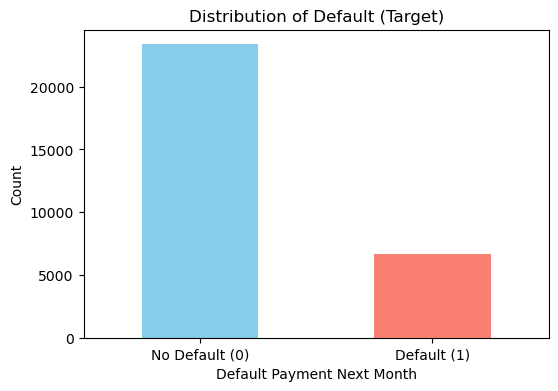

In [29]:
# Plot the distribution of the target variable (default vs. no default)
plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Default (Target)')
plt.xlabel('Default Payment Next Month')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Default (0)', 'Default (1)'], rotation=0)
plt.show()

In [33]:
"Therefore we have an imbalanced data set"

'Therefore we have an imbalanced data set'

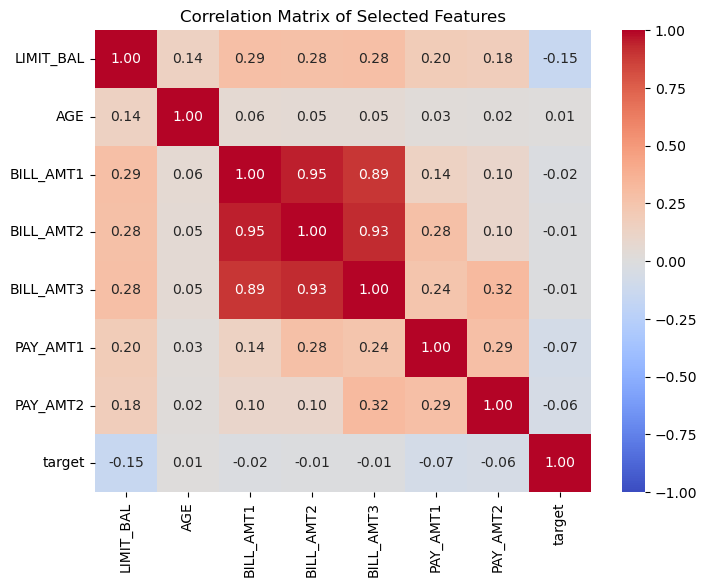

In [30]:
import seaborn as sns

features = df[['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'PAY_AMT1', 'PAY_AMT2', 'target']]
corr_matrix = features.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Selected Features')
plt.show()

In [6]:
# Importing the different classification methods
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB  
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [10]:
# Piling them up in an array : We don't use MultinomialNB since it contains negative values, which is not allowed
classifiers = [LogisticRegression, KNeighborsClassifier, 
               DecisionTreeClassifier, RandomForestClassifier]

models = [classifier() for classifier in classifiers]

In [8]:
PERCENTAGE_SAMPLES_USED_FOR_TESTING = 0.4

train, test = train_test_split(df, test_size=PERCENTAGE_SAMPLES_USED_FOR_TESTING)
print('We are using', len(train),'samples for training the', len(models),'models and',len(test),'samples for testing them later.')

We are using 18000 samples for training the 5 models and 12000 samples for testing them later.


In [11]:

# Training all the models in a loop
for m in models:
    m.fit(train[input_features], train['target'])
    
"""
We can now use them to make predictions for
the test data samples, and compare with the target
values in the test data.

"""
for m in models:
    score = m.score(test[input_features], test['target'])
    print(str(m), ": ",score)

/Users/nikos/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression() :  0.7796666666666666
KNeighborsClassifier() :  0.75225
DecisionTreeClassifier() :  1.0
RandomForestClassifier() :  1.0


In [12]:
# Now we check the balanced accuracies
from sklearn.metrics import balanced_accuracy_score

for m in models:
    predictions = m.predict(test[input_features])
    print()
    print("Balanced Accuracy Scores for", str(m), ":")
    balanced_accuracies = balanced_accuracy_score(test['target'], predictions)
    print(balanced_accuracies)


Balanced Accuracy Scores for LogisticRegression() :
0.49984540282449363

Balanced Accuracy Scores for KNeighborsClassifier() :
0.5515110820570694

Balanced Accuracy Scores for DecisionTreeClassifier() :
1.0

Balanced Accuracy Scores for RandomForestClassifier() :
1.0


In [13]:
"""
In order to see in what classes the Logistic Regression and the KNN perform better we use the confusion matrix
"""
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for m in models:
    predictions = m.predict(test[input_features])
    # cm will be a list of lists (matrix), with the values of the confusion matrix...
    cm = confusion_matrix(test['target'], predictions, labels=m.classes_)
    print()
    print("Confusion matrix for", str(m), ":")
    print(cm)


Confusion matrix for LogisticRegression() :
[[9354   10]
 [2634    2]]

Confusion matrix for KNeighborsClassifier() :
[[8517  847]
 [2126  510]]

Confusion matrix for DecisionTreeClassifier() :
[[9364    0]
 [   0 2636]]

Confusion matrix for RandomForestClassifier() :
[[9364    0]
 [   0 2636]]


Confusion Matrix for  LogisticRegression()


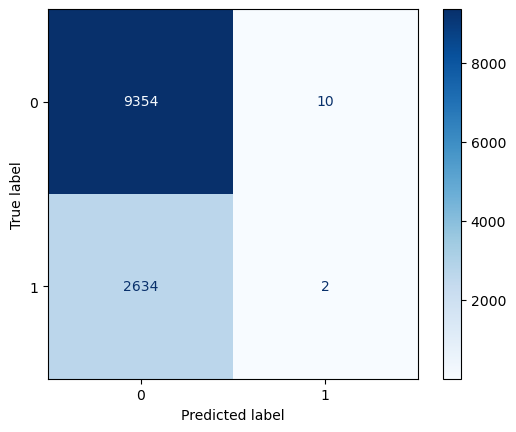

In [14]:
"""
And now we visualize them in a better way
"""
print("Confusion Matrix for ", str(models[0]))
ConfusionMatrixDisplay.from_estimator(models[0], 
                      X=test[input_features], 
                      y=test['target'], 
                      labels=models[0].classes_,
                      cmap='Blues')

Confusion Matrix for  KNeighborsClassifier()


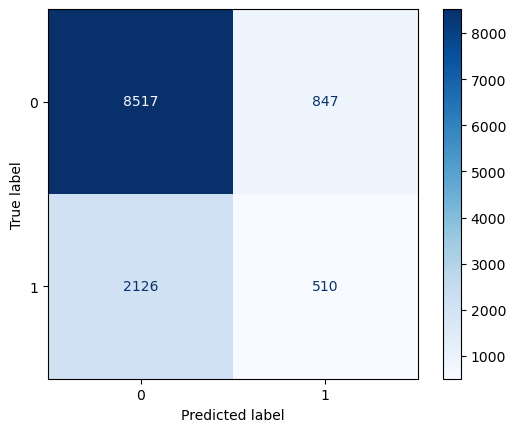

In [15]:
print("Confusion Matrix for ", str(models[1]))
ConfusionMatrixDisplay.from_estimator(models[1], 
                      X=test[input_features], 
                      y=test['target'], 
                      labels=models[1].classes_,
                      cmap='Blues') #We changed the colormap to something less psychodelic than the default

Confusion Matrix for  DecisionTreeClassifier()


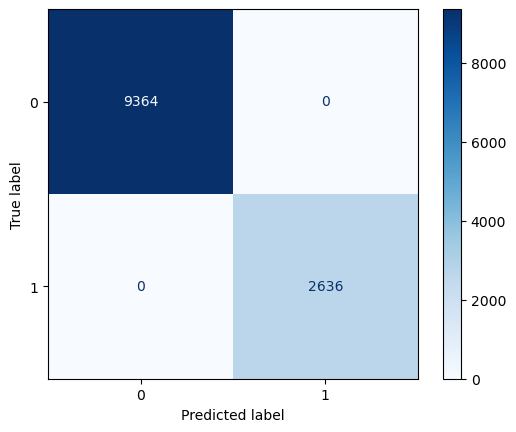

In [16]:
print("Confusion Matrix for ", str(models[2]))
ConfusionMatrixDisplay.from_estimator(models[2], 
                      X=test[input_features], 
                      y=test['target'], 
                      labels=models[2].classes_,
                      cmap='Blues') # We  changed the colormap to something less psychodelic than the default

Confusion Matrix for  RandomForestClassifier()


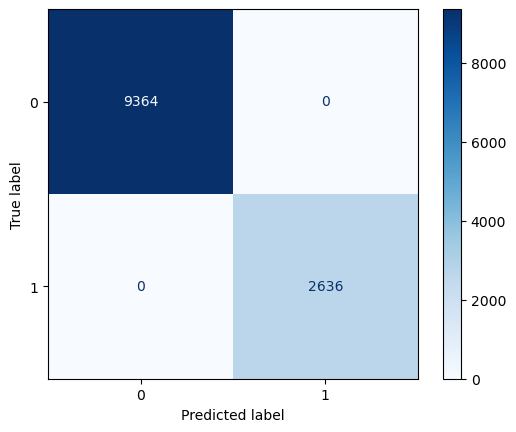

In [17]:
print("Confusion Matrix for ", str(models[3]))
ConfusionMatrixDisplay.from_estimator(models[3], 
                      X=test[input_features], 
                      y=test['target'], 
                      labels=models[3].classes_,
                      cmap='Blues') # We did the same, we changed the colormap to something less psychodelic than the default

In [18]:
"""
Darker diagonals and lighter off-diagonals => better models. So Decision Trees and Random Forests are performing way better
"""

'\nDarker diagonals and lighter off-diagonals => better models. So Decision Trees and Random Forests are performing way better\n'




Confusion matrix for LogisticRegression() :
[[9.98932080e-01 1.06791969e-03]
 [9.99241275e-01 7.58725341e-04]]
  * Accuracies per class: 
     [('Class 0', 1.0), ('Class 1', 0.0)]
  * Balanced Accuracy for  LogisticRegression() :
     0.4998
(this should be the same balanced score value that we calculated above, using the balanced_accuracy_score function)



Confusion matrix for KNeighborsClassifier() :
[[0.9095472  0.0904528 ]
 [0.80652504 0.19347496]]
  * Accuracies per class: 
     [('Class 0', 0.91), ('Class 1', 0.19)]
  * Balanced Accuracy for  KNeighborsClassifier() :
     0.5515
(this should be the same balanced score value that we calculated above, using the balanced_accuracy_score function)



Confusion matrix for DecisionTreeClassifier() :
[[1. 0.]
 [0. 1.]]
  * Accuracies per class: 
     [('Class 0', 1.0), ('Class 1', 1.0)]
  * Balanced Accuracy for  DecisionTreeClassifier() :
     1.0
(this should be the same balanced score value that we calculated above, using the bala

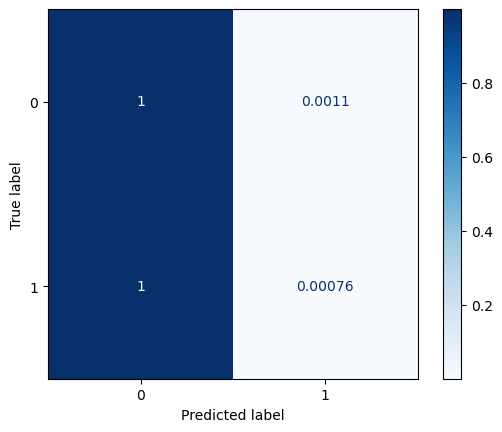

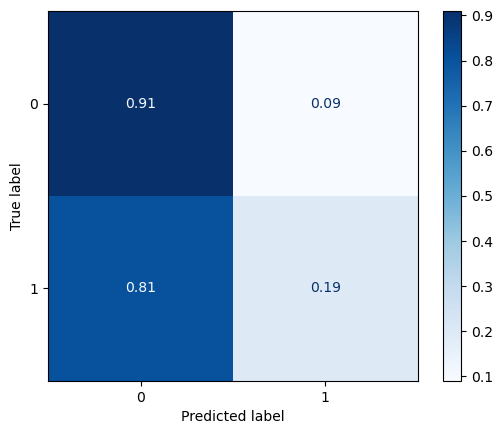

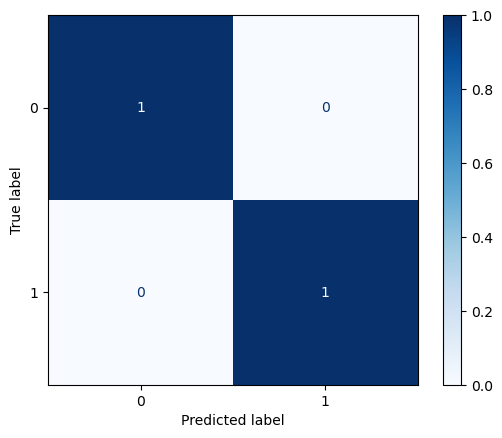

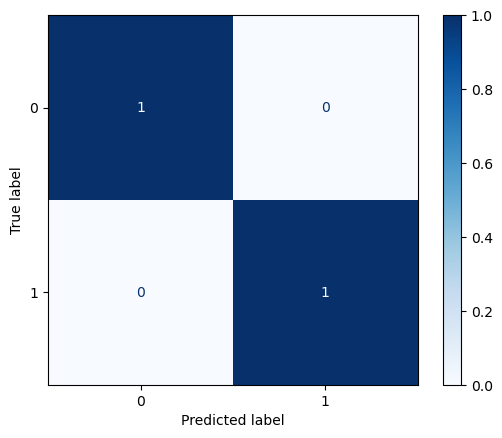

In [20]:
"""
We normalize now the data to see if we get a better accuracy in the first two
"""
for m in models:
    predictions = m.predict(test[input_features])
    # cm will be a list of lists (matrix), with the values of the confusion matrix...
    cm = confusion_matrix(test['target'], predictions, labels=m.classes_, normalize='true')
    print('\n\n')
    print("Confusion matrix for", str(m), ":")
    print(cm)
    print("  * Accuracies per class: ")
    print('    ', list(zip(['Class 0', 'Class 1'], [round(x, 2) for x in cm.diagonal()])))
    print("  * Balanced Accuracy for ", str(m), ":")
    print('    ', round(sum(cm.diagonal())/len(cm.diagonal()), 4))
    print('(this should be the same balanced score value that we calculated above, using the balanced_accuracy_score function)')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=m.classes_)
    disp.plot(cmap='Blues')  


In [31]:
"""
It seems it doesn't help much. 
Logistic regression and KNN are biased towards the majority class since the dataset 
is imbalanced, more "No Default" than "Default". 
"""

'\nIt seems it doesn\'t help much. \nLogistic regression and KNN are biased towards the majority class since the dataset \nis imbalanced, more "No Default" than "Default". \n'

In [23]:
# We now use the classification report to see how according to precision, recall and f1-score how it performs
from sklearn.metrics import classification_report


for m in models:
    predictions = m.predict(test[input_features])
    print('***** Classification report for ', str(m), '***** ')
    print(classification_report(test['target'], predictions))

***** Classification report for  LogisticRegression() ***** 
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      9364
           1       0.17      0.00      0.00      2636

    accuracy                           0.78     12000
   macro avg       0.47      0.50      0.44     12000
weighted avg       0.65      0.78      0.68     12000

***** Classification report for  KNeighborsClassifier() ***** 
              precision    recall  f1-score   support

           0       0.80      0.91      0.85      9364
           1       0.38      0.19      0.26      2636

    accuracy                           0.75     12000
   macro avg       0.59      0.55      0.55     12000
weighted avg       0.71      0.75      0.72     12000

***** Classification report for  DecisionTreeClassifier() ***** 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9364
           1       1.00      1.00      1.00     

In [35]:
## Example of hypothesis testing for SEX. We use statsmodels for hypothesis testing
import statsmodels.api as sm

# Prepare the data for logistic regression
X = df[['SEX', 'AGE', 'BILL_AMT1']]  # Select a few features for simplicity
X = sm.add_constant(X)  # Add intercept term
y = df['target']

# Fit logistic regression model
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

# Checking the p-value for 'SEX'
p_value_limit_bal = result.pvalues['SEX']
print(f"P-value for SEX: {p_value_limit_bal}")

    

Optimization terminated successfully.
         Current function value: 0.527339
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                30000
Model:                          Logit   Df Residuals:                    29996
Method:                           MLE   Df Model:                            3
Date:                Thu, 01 May 2025   Pseudo R-squ.:                0.002051
Time:                        18:51:18   Log-Likelihood:                -15820.
converged:                       True   LL-Null:                       -15853.
Covariance Type:            nonrobust   LLR p-value:                 4.938e-14
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0203      0.075    -13.662      0.000      -1.167      -0.874
SEX           -0.1935      0.

In [36]:
# Low p-value means great significance 